# Lab assignment №1, part 2

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the second part of the assignment. First and third parts are waiting for you in the same directory.*__

## Part 2. Data preprocessing, model training and evaluation.

### 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [51]:
# If on colab, uncomment the following lines

# ! wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('car_data.csv', delimiter=',', header=None).values
data = dataset[:, :-1].astype(int)
target = dataset[:, -1]

print(data.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.35)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(846, 19) (846,)
(549, 19) (549,) (297, 19) (297,)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [53]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,29,80,38,63,129,55,7,146,46,19,130,168,314,158,83,9,20,180,185
1,22,94,43,64,173,69,7,150,43,19,142,169,344,177,68,9,1,199,206
2,18,104,54,100,186,61,10,216,31,24,173,225,686,220,74,5,11,185,195
3,787,93,37,70,126,52,9,127,53,18,137,156,238,119,71,2,13,191,190
4,676,82,43,73,158,68,7,151,44,19,145,181,337,173,80,2,17,183,188
5,833,92,46,83,154,56,6,160,41,20,148,185,382,184,71,10,5,186,191
6,183,84,35,53,122,57,4,116,59,17,123,135,196,128,76,10,27,183,190
7,188,101,51,105,212,68,10,209,32,24,162,222,653,224,73,5,23,186,195
8,170,108,51,103,197,60,11,211,31,24,160,222,661,187,67,7,3,190,200
9,345,101,54,106,188,57,7,236,28,26,164,256,833,253,81,6,14,185,185


Methods `describe` and `info` deliver some useful information.

In [54]:
X_train_pd.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,422.890710,93.599271,44.863388,81.743169,168.459016,61.717668,8.590164,168.378871,41.054645,20.559199,148.100182,188.269581,437.431694,174.575592,72.646630,6.369763,12.744991,188.759563,195.435337
std,243.229659,8.209155,6.090071,15.616807,34.252133,8.515897,4.780737,33.244757,7.828961,2.596786,14.338166,31.516364,176.598129,32.060279,7.608275,4.922008,8.779154,6.166821,7.437937
min,1.000000,76.000000,33.000000,40.000000,104.000000,47.000000,3.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,219.000000,88.000000,40.000000,70.000000,139.000000,57.000000,6.000000,147.000000,33.000000,19.000000,137.000000,167.000000,318.000000,150.000000,68.000000,2.000000,6.000000,184.000000,190.000000
50%,422.000000,93.000000,44.000000,80.000000,166.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,177.000000,362.000000,173.000000,72.000000,5.000000,11.000000,188.000000,196.000000
75%,638.000000,100.000000,49.000000,96.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,216.000000,587.000000,198.000000,76.000000,9.000000,19.000000,193.000000,201.000000
max,843.000000,117.000000,58.000000,112.000000,333.000000,138.000000,52.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000


In [55]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       549 non-null    int64
 1   1       549 non-null    int64
 2   2       549 non-null    int64
 3   3       549 non-null    int64
 4   4       549 non-null    int64
 5   5       549 non-null    int64
 6   6       549 non-null    int64
 7   7       549 non-null    int64
 8   8       549 non-null    int64
 9   9       549 non-null    int64
 10  10      549 non-null    int64
 11  11      549 non-null    int64
 12  12      549 non-null    int64
 13  13      549 non-null    int64
 14  14      549 non-null    int64
 15  15      549 non-null    int64
 16  16      549 non-null    int64
 17  17      549 non-null    int64
 18  18      549 non-null    int64
dtypes: int64(19)
memory usage: 81.6 KB


### 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

#### 2.0. Data preprocessing
* Make some transformations of the dataset (if necessary). Briefly explain the transformations

- Основным преобразованием является One-Hot Encoding категориальных признаков. Оно гарантирует, что модель логистической регрессии будет трактовать каждую категорию как независимое номинальное значение, а не как численно упорядоченную величину (что подразумевало бы целочисленное представление).
- Данное преобразование необходимо для того, чтобы модели логистической регрессии правильно интерпретировали данные. Количество признаков увеличивается после этого преобразования.
- Наши данные не имеют пропусков, но если бы таковые были, строки с ними необходимо было бы удалить или заполнить.
- Масштабировать признаки нет необходимости, данные в одном масштабе.

In [56]:
### YOUR CODE HERE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features_indices = list(range(X_train.shape[1]))
one_hot = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('category', one_hot, categorical_features_indices)
    ],
    remainder='passthrough')

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(f"Исходная форма обучающего набора: {X_train.shape}")
print(f"Форма закодированного обучающего набора: {X_train_encoded.shape}")
print(f"Исходная форма тестового набора: {X_test.shape}")
print(f"Форма закодированного тестового набора: {X_test_encoded.shape}")

Исходная форма обучающего набора: (549, 19)
Форма закодированного обучающего набора: (549, 1836)
Исходная форма тестового набора: (297, 19)
Форма закодированного тестового набора: (297, 1836)


#### 2.1. Basic logistic regression
* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [57]:
!pip install scikit-plot

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Лучшие гиперпараметры: {'C': 1}

Точность (Accuracy) на тестовом наборе: 0.6566
F1-мера (F1-Score) на тестовом наборе: 0.6489



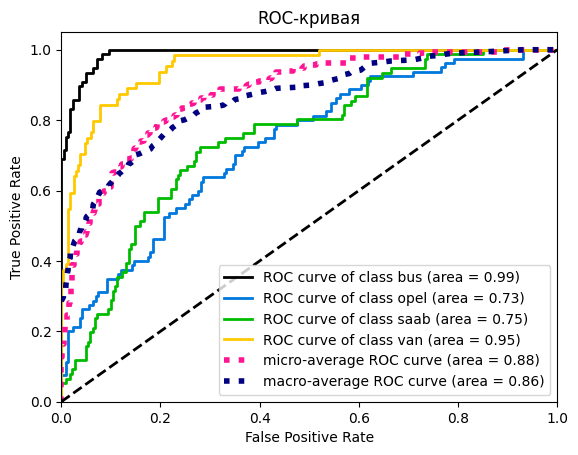

In [58]:
### YOUR CODE HERE

import scipy
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
scipy.interp = np.interp
import scikitplot as skplt

# 1. Определение модели и гиперпараметров
log_reg_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    tol=1e-3,
    max_iter=500
)

# Меньшие значения C означают более сильную регуляризацию.
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# 2. Поиск по сетке с кросс-валидацией
grid_search = GridSearchCV(
    estimator=log_reg_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train_encoded, y_train)

# 3. Оценка модели
best_log_reg_model = grid_search.best_estimator_

y_pred = best_log_reg_model.predict(X_test_encoded)
y_pred_proba = best_log_reg_model.predict_proba(X_test_encoded)

print(f"Лучшие гиперпараметры: {grid_search.best_params_}\n")

# Оцениваем качество модели
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Точность (Accuracy) на тестовом наборе: {accuracy:.4f}")
print(f"F1-мера (F1-Score) на тестовом наборе: {f1:.4f}\n")

# 4. Построение ROC-кривой
skplt.metrics.plot_roc(y_test, y_pred_proba)
plt.title("ROC-кривая")
plt.show()

#### 2.2. PCA: explained variance plot
* Apply the PCA to the train part of the data. Build the explaided variance plot.

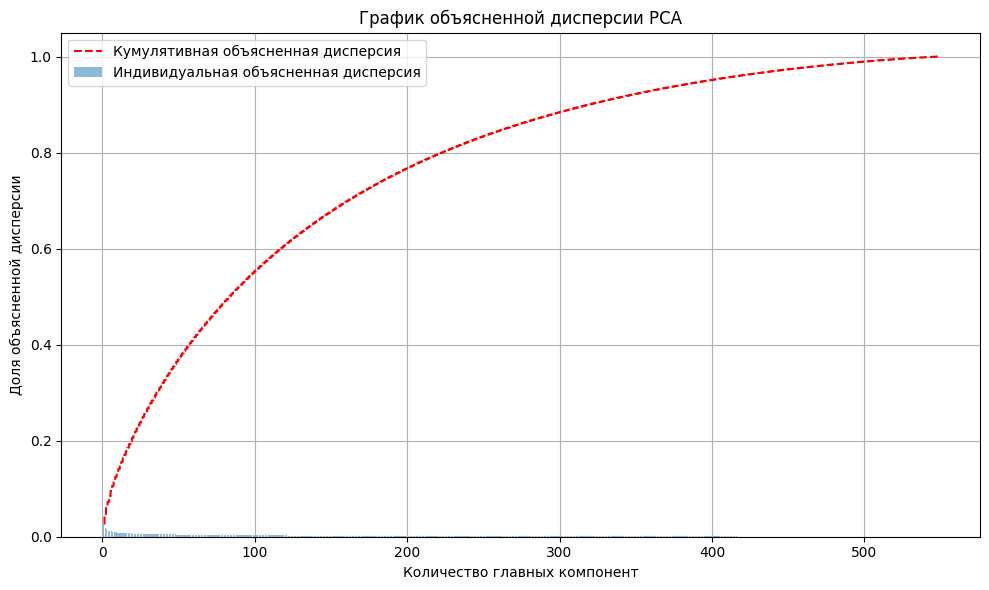

Общее количество признаков после кодирования: 1836
Компонент для 90% дисперсии: 320


In [59]:
### YOUR CODE HERE

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Применяем PCA к обучающим данным
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_encoded)
X_test_pca = pca.transform(X_test_encoded)

# 2. Построение графика объясненной дисперсии
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center',
        label='Индивидуальная объясненная дисперсия')

# График кумулятивной дисперсии
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Кумулятивная объясненная дисперсия', color='red', linestyle='--')

plt.ylabel('Доля объясненной дисперсии')
plt.xlabel('Количество главных компонент')
plt.title('График объясненной дисперсии PCA')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

components_90_perc = np.argmax(cumulative_variance >= 0.90) + 1
components_95_perc = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Общее количество признаков после кодирования: {X_train_encoded.shape[1]}")
print(f"Компонент для 90% дисперсии: {components_90_perc}")

#### 2.3. PCA trasformation
* Select the appropriate number of components. Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train` and `test` parts.*

Выбираем 320 главных компонент:
На предыдущем шаге (2.2) мы выяснили, что 320 компонент объясняет 90% общей дисперсии в исходных данных:
- Сокращение количества признаков более чем в 5 раз (с 1830 до 320).
- Сохранение большинства (90%) полезной информации, что достаточно для построения качественной модели.

Данные нормализовать не требуется.

PCA чувствителен к масштабу данных. В начале выполнен One-Hot Encoding, поэтому признаки теперь представляют собой бинарные значения (0 или 1), и все они находятся в одном и том же масштабе. Нормализация бинарных данных не имеет смысла и может даже ухудшить интерпретируемость.

In [60]:
### YOUR CODE HERE

N_COMPONENTS = 320
pca = PCA(n_components=N_COMPONENTS)
X_train_pca = pca.fit_transform(X_train_encoded)
X_test_pca = pca.transform(X_test_encoded)

print(f"Исходная форма обучающего набора после OHE: {X_train_encoded.shape}")
print(f"Новая форма обучающего набора после PCA: {X_train_pca.shape}")
print(f"Новая форма тестового набора после PCA: {X_test_pca.shape}")

Исходная форма обучающего набора после OHE: (549, 1836)
Новая форма обучающего набора после PCA: (549, 320)
Новая форма тестового набора после PCA: (297, 320)


#### 2.4. Logistic regression on PCA-preprocessed data.
* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Лучшие гиперпараметры для модели с PCA: {'C': 1}

Точность (Accuracy) на тестовом наборе с PCA: 0.6364
F1-мера (F1-Score) на тестовом наборе с PCA: 0.6313



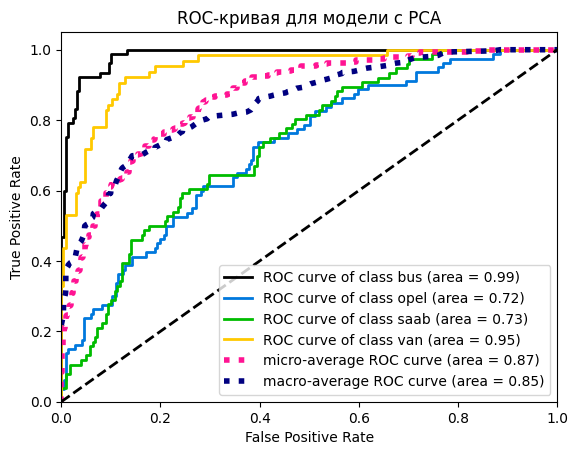

In [61]:
### YOUR CODE HERE

# 1. Определение модели и сетки гиперпараметров
log_reg_pca_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    tol=1e-3,
    max_iter=500
)

param_grid_pca = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# 2. Поиск по сетке с кросс-валидацией
grid_search_pca = GridSearchCV(
    estimator=log_reg_pca_model,
    param_grid=param_grid_pca,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search_pca.fit(X_train_pca, y_train)

# 3. Оценка модели
best_log_reg_pca_model = grid_search_pca.best_estimator_

y_pred_pca = best_log_reg_pca_model.predict(X_test_pca)
y_pred_proba_pca = best_log_reg_pca_model.predict_proba(X_test_pca)
print(f"Лучшие гиперпараметры для модели с PCA: {grid_search_pca.best_params_}\n")

# Оцениваем качество модели
accuracy_pca = accuracy_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca, average='weighted')

print(f"Точность (Accuracy) на тестовом наборе с PCA: {accuracy_pca:.4f}")
print(f"F1-мера (F1-Score) на тестовом наборе с PCA: {f1_pca:.4f}\n")

# 4. Построение ROC-кривой
skplt.metrics.plot_roc(y_test, y_pred_proba_pca)
plt.title("ROC-кривая для модели с PCA")
plt.show()

**Анализ результатов**

Общее качество немного снизилось:
Использование PCA привело к небольшому падению общей точности и F1-меры. Это ожидаемо: удалив 10% дисперсии данных, неизбежно потеряли немного информации, которая была полезна для классификации.

На оригинальных данных лучшим был C=1.0, а на данных с PCA C=0.1. Снижение оптимального C означает, что модель на данных PCA требует более сильной регуляризации. Это может быть связано с тем, что сами PCA-компоненты более "плотные" по информации или имеют другую структуру, которая требует большего контроля над весами модели.

Хотя модель стала немного менее точной, она, вероятно, обучалась значительно быстрее.

#### 2.5. Decision tree
* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

In [62]:
from sklearn.tree import DecisionTreeClassifier

# YOUR CODE HERE

# 1. Определение модели и сетки гиперпараметров
dt_model = DecisionTreeClassifier(random_state=42) # random_state для воспроизводимости

param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20, 30, 50] # Диапазон глубин для проверки
}

# 2. Поиск по сетке с кросс-валивацией
grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search_dt.fit(X_train_pca, y_train)

# 3. Оценка модели
best_dt_model = grid_search_dt.best_estimator_

y_pred_dt = best_dt_model.predict(X_test_pca)
y_pred_proba_dt = best_dt_model.predict_proba(X_test_pca)

print(f"Лучшие гиперпараметры для дерева решений (PCA данные): {grid_search_dt.best_params_}\n")

# Оцениваем качество модели
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print(f"Точность (Accuracy) на тестовом наборе с PCA: {accuracy_dt:.4f}")
print(f"F1-мера (F1-Score) на тестовом наборе с PCA: {f1_dt:.4f}\n")

Лучшие гиперпараметры для дерева решений (PCA данные): {'max_depth': 5}

Точность (Accuracy) на тестовом наборе с PCA: 0.5118
F1-мера (F1-Score) на тестовом наборе с PCA: 0.4939



Результаты показывают, что в данном случае логистическая регрессия является более подходящей моделью, чем дерево решений, на данных, преобразованных с помощью PCA.

#### 2.6. Bagging.
Here starts the ensembling part.

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ (with step 5).

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble?

Ансамбль логистических регрессий
Ансамбль деревьев решений


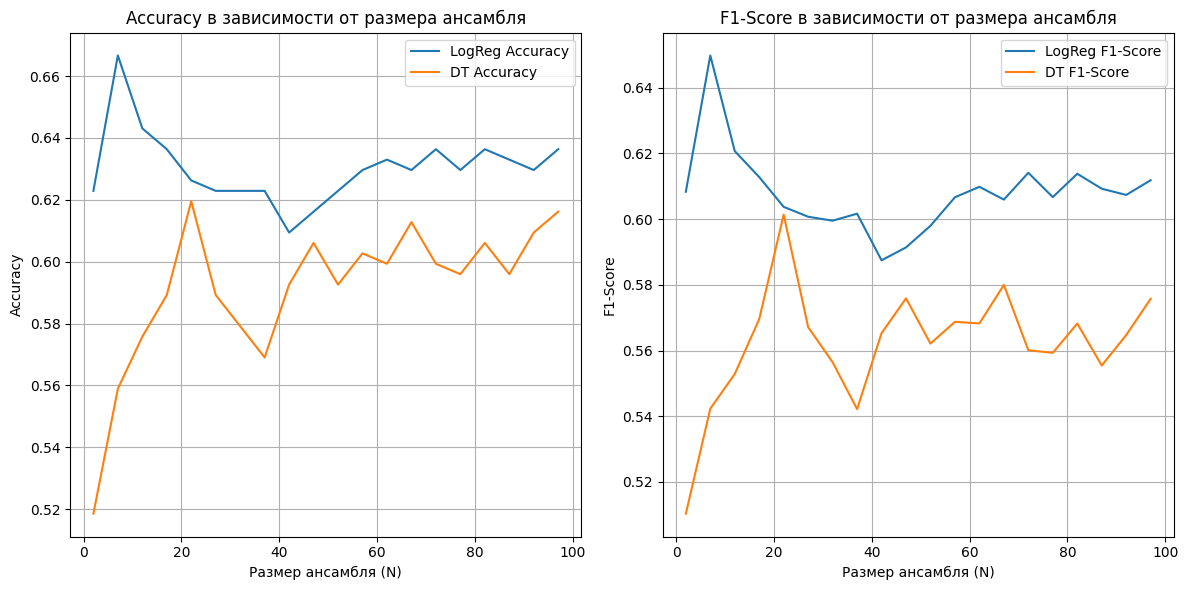

In [63]:
# YOUR CODE HERE

from sklearn.ensemble import BaggingClassifier

BEST_C = 0.1
BEST_MAX_DEPTH = 5
N_MIN = 2
N_MAX = 100
STEP = 5

print("Ансамбль логистических регрессий")

log_reg_bagging = BaggingClassifier(
    estimator=LogisticRegression(
        multi_class='multinomial', solver='saga', tol=1e-3, max_iter=500, C=BEST_C),
    n_estimators=N_MAX,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

log_reg_bagging.fit(X_train_pca, y_train)

log_reg_f1_scores = []
log_reg_acc_scores = []
ensemble_sizes = range(N_MIN, N_MAX + 1, STEP)

for n in ensemble_sizes:
    y_pred_proba = np.array([
        est.predict_proba(X_test_pca) for est in log_reg_bagging.estimators_[:n]
    ])

    y_pred_proba_avg = np.mean(y_pred_proba, axis=0)
    y_pred = log_reg_bagging.classes_[np.argmax(y_pred_proba_avg, axis=1)]

    log_reg_f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
    log_reg_acc_scores.append(accuracy_score(y_test, y_pred))

print("Ансамбль деревьев решений")

dt_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=BEST_MAX_DEPTH, random_state=42),
    n_estimators=N_MAX,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

dt_bagging.fit(X_train_pca, y_train)

dt_f1_scores = []
dt_acc_scores = []

for n in ensemble_sizes:
    y_pred_proba = np.array([
        est.predict_proba(X_test_pca) for est in dt_bagging.estimators_[:n]
    ])

    y_pred_proba_avg = np.mean(y_pred_proba, axis=0)
    y_pred = dt_bagging.classes_[np.argmax(y_pred_proba_avg, axis=1)]

    dt_f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
    dt_acc_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(ensemble_sizes, log_reg_acc_scores, label='LogReg Accuracy')
plt.plot(ensemble_sizes, dt_acc_scores, label='DT Accuracy')
plt.xlabel('Размер ансамбля (N)')
plt.ylabel('Accuracy')
plt.title('Accuracy в зависимости от размера ансамбля')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ensemble_sizes, log_reg_f1_scores, label='LogReg F1-Score')
plt.plot(ensemble_sizes, dt_f1_scores, label='DT F1-Score')
plt.xlabel('Размер ансамбля (N)')
plt.ylabel('F1-Score')
plt.title('F1-Score в зависимости от размера ансамбля')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Каково оптимальное количество алгоритмов?

Для логистической регрессии, оптимальное N находится очень рано, возможно N=21,поскольку качество в целом стабильно.
Для дерева решений качество стабилизируется примерно после N=40-50, хотя и с небольшими колебаниями.

Как вы думаете, являются ли гиперпараметры для деревьев решений, которые вы нашли в 2.5, оптимальными для деревьев, используемых в ансамбле?

Скорее всего, нет.
В задании 2.5 мы искали оптимальные параметры (max_depth=5) для одиночного, независимого дерева решений, которое должно работать хорошо само по себе.
В ансамбле бэггинга часто используют "слабые" модели. Для дерева решений это обычно означает большую глубину.
Использование неглубокого дерева (max_depth=5) снижает его дисперсию, делая его менее "идеальным" базовым классификатором для бэггинга.

#### 2.7. Random Forest
Now we will work with the Random Forest (its `sklearn` implementation).

* * Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

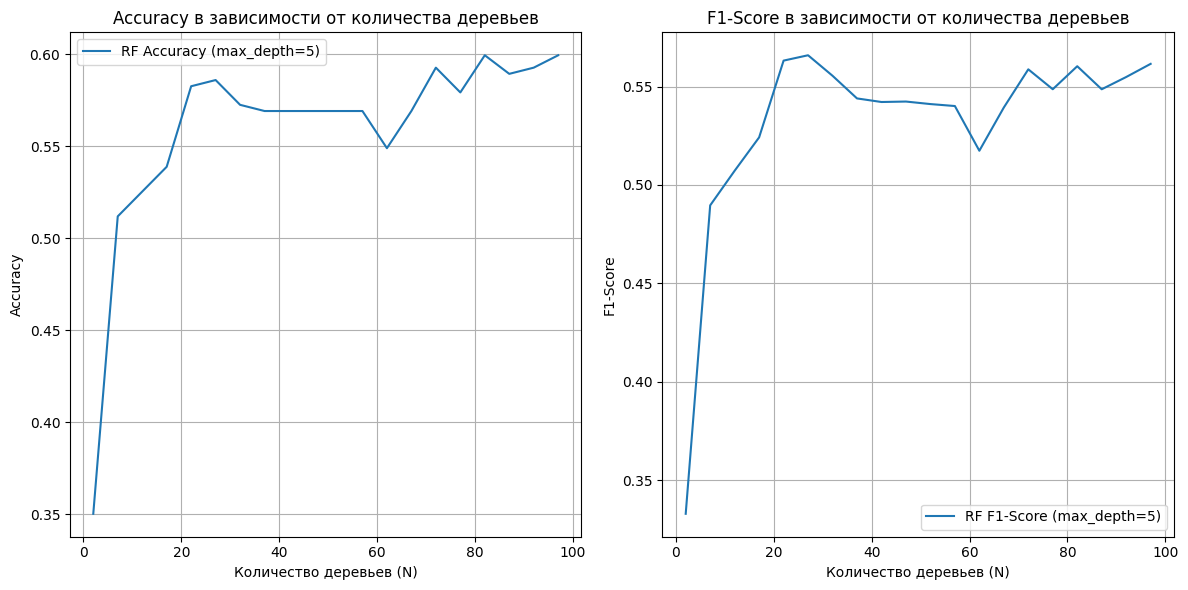

In [64]:
from sklearn.ensemble import RandomForestClassifier

# YOUR CODE HERE

from sklearn.ensemble import RandomForestClassifier

BEST_MAX_DEPTH = 5
N_MIN = 2
N_MAX = 100
STEP = 5

rf_f1_scores = []
rf_acc_scores = []
ensemble_sizes = range(N_MIN, N_MAX + 1, STEP)

for n in ensemble_sizes:
    rf_model = RandomForestClassifier(
        n_estimators=n,
        max_depth=BEST_MAX_DEPTH,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_pca, y_train)

    y_pred = rf_model.predict(X_test_pca)

    rf_acc_scores.append(accuracy_score(y_test, y_pred))
    rf_f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(ensemble_sizes, rf_acc_scores, label=f'RF Accuracy (max_depth={BEST_MAX_DEPTH})')
plt.xlabel('Количество деревьев (N)')
plt.ylabel('Accuracy')
plt.title('Accuracy в зависимости от количества деревьев')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ensemble_sizes, rf_f1_scores, label=f'RF F1-Score (max_depth={BEST_MAX_DEPTH})')
plt.xlabel('Количество деревьев (N)')
plt.ylabel('F1-Score')
plt.title('F1-Score в зависимости от количества деревьев')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Оптимальное количество деревьев:

Метрики (Accuracy и F1) достигают максимума при N = 95 дереве, после чего наблюдаются колебания. Стабилизация начинается примерно после N=40.
Оптимальным количеством деревьев можно считать N=95, так как в этой точке достигается наилучший результат.

В этой задаче логистическая регрессия остается лучшей моделью.

#### 2.8. Learning curve
Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected on 1 part, 2 parts (combined, so the train size in increased by 2 times), 3 parts and so on.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score - dataset size.

* Analyse the final plot. Can you make any conlusions using it?

Обучение на 494 примерах


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Обучение на 988 примерах


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Обучение на 1482 примерах


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Обучение на 4446 примерах


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Обучение на 4941 примерах


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


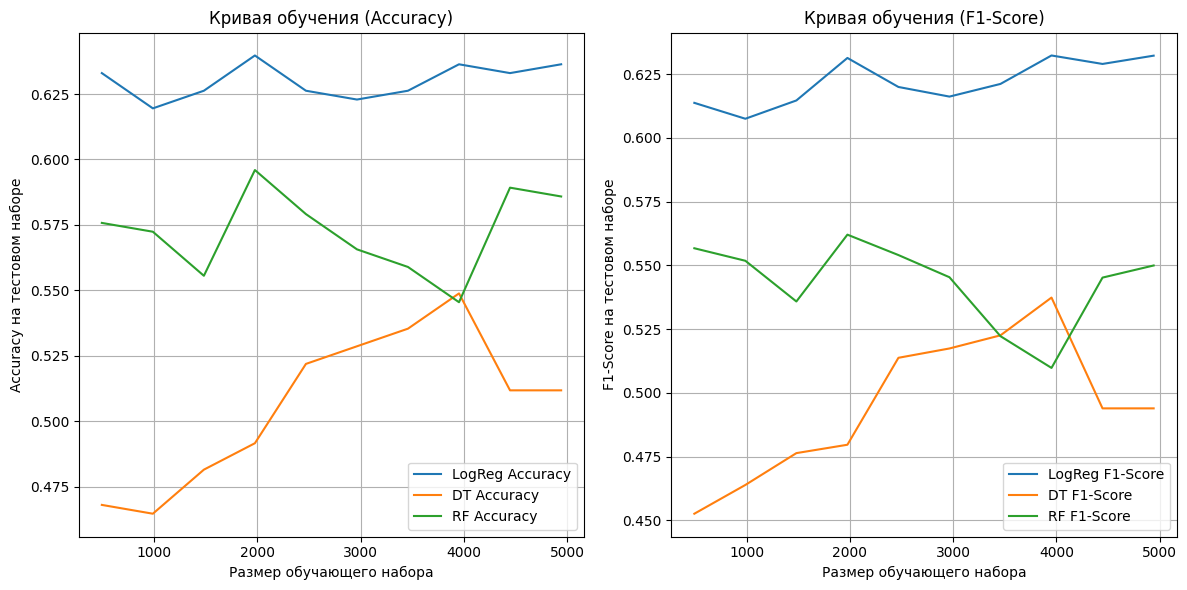

In [65]:
# YOUR CODE HERE

from sklearn.model_selection import KFold

BEST_LOGREG_C = 0.1
BEST_DT_MAX_DEPTH = 5
BEST_RF_MAX_DEPTH = 5
BEST_RF_N_ESTIMATORS = 61

kf = KFold(n_splits=10, shuffle=True, random_state=42)
train_indices = list(kf.split(X_train_pca))

train_sizes = []
logreg_acc_scores = []
logreg_f1_scores = []
dt_acc_scores = []
dt_f1_scores = []
rf_acc_scores = []
rf_f1_scores = []

for i in range(1, 11):
    current_train_indices = np.concatenate([train_indices[j][0] for j in range(i)])
    X_train_subset = X_train_pca[current_train_indices]
    y_train_subset = y_train[current_train_indices]
    train_sizes.append(X_train_subset.shape[0])

    print(f"Обучение на {X_train_subset.shape[0]} примерах")

    # Обучение Логистической регрессии
    logreg = LogisticRegression(
        multi_class='multinomial', solver='saga', tol=1e-3, max_iter=500, C=BEST_LOGREG_C, random_state=42
    )
    logreg.fit(X_train_subset, y_train_subset)
    y_pred = logreg.predict(X_test_pca)
    logreg_acc_scores.append(accuracy_score(y_test, y_pred))
    logreg_f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

    # Обучение Дерева решений
    dt = DecisionTreeClassifier(max_depth=BEST_DT_MAX_DEPTH, random_state=42)
    dt.fit(X_train_subset, y_train_subset)
    y_pred = dt.predict(X_test_pca)
    dt_acc_scores.append(accuracy_score(y_test, y_pred))
    dt_f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

    # Обучение Случайного леса
    rf = RandomForestClassifier(
        n_estimators=BEST_RF_N_ESTIMATORS, max_depth=BEST_RF_MAX_DEPTH, random_state=42, n_jobs=-1
    )
    rf.fit(X_train_subset, y_train_subset)
    y_pred = rf.predict(X_test_pca)
    rf_acc_scores.append(accuracy_score(y_test, y_pred))
    rf_f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_sizes, logreg_acc_scores, label='LogReg Accuracy')
plt.plot(train_sizes, dt_acc_scores, label='DT Accuracy')
plt.plot(train_sizes, rf_acc_scores, label='RF Accuracy')
plt.xlabel('Размер обучающего набора')
plt.ylabel('Accuracy на тестовом наборе')
plt.title('Кривая обучения (Accuracy)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_sizes, logreg_f1_scores, label='LogReg F1-Score')
plt.plot(train_sizes, dt_f1_scores, label='DT F1-Score')
plt.plot(train_sizes, rf_f1_scores, label='RF F1-Score')
plt.xlabel('Размер обучающего набора')
plt.ylabel('F1-Score на тестовом наборе')
plt.title('Кривая обучения (F1-Score)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Кривые обучения подтверждают, что логистическая регрессия является наиболее подходящей моделью для вашего набора данных после PCA. Она эффективна, стабильна и показывает наилучшие результаты.

1. Модель Логистической регрессии — лидер:

Из графиков видно, что Логистическая регрессия превосходит Дерево решений и Случайный лес по метрикам Accuracy и F1 на всех размерах обучающего набора данных.

2. Логистическая регрессия демонстрирует высокую эффективность использования данных: она достигает хорошего качества уже на малых объемах выборки. Древовидные модели требуют больше данных для достижения своих (пусть и более низких) пиков.

3. Все кривые, хоть и имеют пики и спады, к концу диапазона (N=5000) не показывают явного выхода на плато с постоянным ростом. Это может означать, что если бы у вас было еще больше данных (например, N=10000), производительность могла бы продолжить расти (особенно для DT и RF).

#### 2.9. Boosting
Your goal is to build a boosting ensemble using xgboost, CatBoost or lightgbm package.
Please, do not use the sklearn API for these models.

Find optimal number of decision trees in the boosting ensembe using grid search or other methods.
Please, explain your answer.

In [66]:
# YOUR CODE HERE

!pip install xgboost

In [67]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded_labels = le.fit_transform(y_train)
y_test_encoded_labels = le.transform(y_test)

dtrain = xgb.DMatrix(X_train_pca, label=y_train_encoded_labels)
dtest = xgb.DMatrix(X_test_pca, label=y_test_encoded_labels)

params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'eta': 0.1,
    'max_depth': 5,
    'num_class': len(np.unique(y_train_encoded_labels)),
    'seed': 42,
    'verbosity': 0
}

cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    nfold=5,
    early_stopping_rounds=50,
    metrics=['mlogloss', 'merror'],
    seed=42,
    verbose_eval=True
)

# Оптимальное количество деревьев
optimal_n_estimators = cv_results.shape[0]
best_mlogloss = cv_results['test-mlogloss-mean'].min()

print(f"\nОптимальное количество деревьев (n_estimators): {optimal_n_estimators}")
print(f"Лучший mlogloss при CV: {best_mlogloss:.4f}")

# Обучение финальной модели с оптимальным количеством деревьев
final_xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=optimal_n_estimators
)

y_pred_proba_xgb = final_xgb_model.predict(dtest)
y_pred_xgb_encoded = np.argmax(y_pred_proba_xgb, axis=1)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"\nТочность (Accuracy) на тестовом наборе (XGBoost): {accuracy_xgb:.4f}")
print(f"F1-мера (Weighted F1-Score) на тестовом наборе (XGBoost): {f1_xgb:.4f}")

[0]	train-mlogloss:1.27543+0.00552	train-merror:0.14753+0.01947	test-mlogloss:1.34318+0.00545	test-merror:0.52277+0.02473
[1]	train-mlogloss:1.17903+0.00742	train-merror:0.11065+0.00958	test-mlogloss:1.30595+0.00878	test-merror:0.49908+0.04345
[2]	train-mlogloss:1.09112+0.00787	train-merror:0.08014+0.01440	test-mlogloss:1.27575+0.01173	test-merror:0.49545+0.03069
[3]	train-mlogloss:1.01291+0.00815	train-merror:0.06057+0.01409	test-mlogloss:1.24883+0.02136	test-merror:0.48992+0.04407
[4]	train-mlogloss:0.94147+0.00907	train-merror:0.04600+0.01193	test-mlogloss:1.22688+0.02669	test-merror:0.48080+0.03370
[5]	train-mlogloss:0.87696+0.00933	train-merror:0.04099+0.00924	test-mlogloss:1.20669+0.03720	test-merror:0.47711+0.04249
[6]	train-mlogloss:0.81681+0.01001	train-merror:0.03143+0.00796	test-mlogloss:1.18891+0.04090	test-merror:0.47528+0.04459
[7]	train-mlogloss:0.76372+0.01133	train-merror:0.02641+0.00730	test-mlogloss:1.17674+0.05061	test-merror:0.46977+0.05505
[8]	train-mlogloss:0.714

- Модель бустинга (XGBoost) показала очень сильный результат, практически сравнимый с лучшей моделью — логистической регрессией. Это подтверждает высокую эффективность бустинга как ансамблевого метода.

- XGBoost обучен на данных с PCA (320 признаков), в то время как лучшая LogReg обучалась на полных данных (1830 признаков). XGBoost достигает почти такой же точности на сжатых данных.

- Простая логистическая регрессия без PCA оказалась самой эффективной моделью для данной задачи классификации. XGBoost — вторая по эффективности модель.